In [1]:
import multiprocessing

multiprocessing.cpu_count()

36

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

paradigm = P300(resample=48)

datasets = [
    BNCI2014_008(),
    #BNCI2015_003(),
    #BNCI2014_009(),
    #BI2012(),
    #BI2013a(),                               
    #BI2014a(),
    #DemonsP300(),
    #Cattan2019_VR(),
    #EPFLP300(),
    #BI2015a(),   
    #BI2015b(),
    #BI2014b(),
    #Lee2019_ERP(),
    #Huebner2017(),
    #Huebner2018(),
    #Sosulski2019(),
]



In [3]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper,ZScore
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from hoda.classification import SelectF
import tensorly as tl

pipelines=dict()

cv=StratifiedKFold(random_state=42, shuffle=True)


hoda_params = dict(
    max_iter=64,
    tol=1e-8,
    init ='random',
    random_state=42,
    shrinkage='oas',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='tr',
    toeplitz=None,
    delta=None,
    extra_train_info=False,
)

bttda_params=dict(
        truncate=True,
        n_jobs=1,
        hoda_params=hoda_params,
        extra_train_info=False,
        verbose=False,
        cv=cv,
)


clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LDA(shrinkage='auto', solver='lsqr')
)

pipelines['HODA'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=1,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])

pipelines['BTTDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])

pipelines['PARAFACDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        **bttda_params,
        clf=clf,
        rank_grid=[1],
    )),
    ('clf', clf)
])


In [4]:
import pandas as pd

results = []
for dataset in datasets:
    print(dataset.code)
    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=False,
        random_state=42,
        n_jobs=5,
        suffix=f'bttda_rev2_{dataset.code}',
    )
    results.append(evaluation.process(pipelines, postprocess_pipeline=FunctionTransformer(tl.tensor)))
results = pd.concat(results)

BNCI2014-008


BNCI2014-008-WithinSession:   0%|          | 0/8 [00:00<?, ?it/s]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  12%|█▎        | 1/8 [08:24<58:49, 504.26s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


...

BNCI2014-008-WithinSession:  75%|███████▌  | 6/8 [47:56<16:11, 485.99s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|████████▊ | 7/8 [58:35<08:55, 535.79s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|██████████| 8/8 [1:08:28<00:00, 513.60s/it]


In [5]:
results.to_csv('moabb_results_erp.csv')

In [6]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.828861,7.933655,4200.0,1,0,8,1,BNCI2014-008,HODA
1,0.781241,7.802560,4200.0,2,0,8,1,BNCI2014-008,HODA
2,0.864810,5.668575,4200.0,3,0,8,1,BNCI2014-008,HODA
3,0.800788,2.023287,4200.0,4,0,8,1,BNCI2014-008,HODA
4,0.845759,2.247558,4200.0,5,0,8,1,BNCI2014-008,HODA
5,0.850492,7.284207,4200.0,6,0,8,1,BNCI2014-008,HODA
6,0.856098,7.119827,4200.0,7,0,8,1,BNCI2014-008,HODA
7,0.942498,7.064200,4200.0,8,0,8,1,BNCI2014-008,HODA
8,0.835929,10.910799,4200.0,1,0,8,1,BNCI2014-008,PARAFACDA_10
9,0.810945,11.308770,4200.0,2,0,8,1,BNCI2014-008,PARAFACDA_10


In [7]:
(results.groupby(['dataset', 'pipeline']).score.aggregate(['mean', 'std'])*100 ).round(2)

mean   std
dataset      pipeline                     
BNCI2014-008 BTTDA_10      86.089996  4.83
             HODA          84.629997  4.83
             PARAFACDA_10  86.059998  4.62

##### results

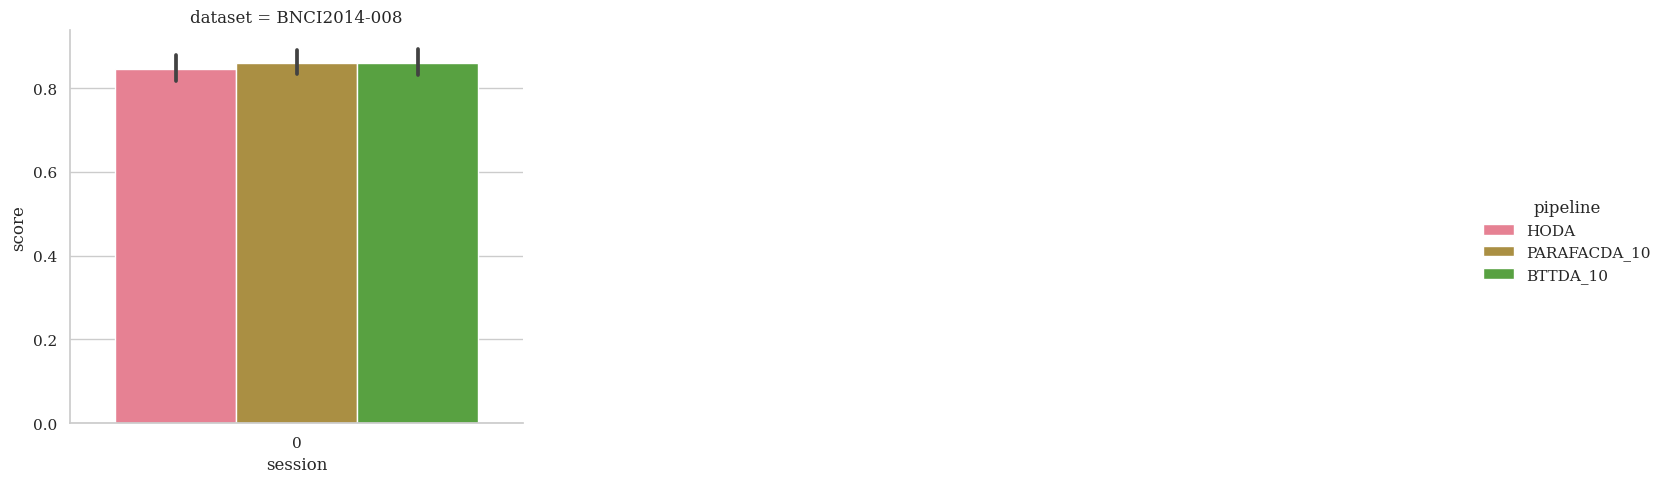

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , x='session', y='score', col='dataset',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

<Axes: xlabel='pipeline', ylabel='score'>

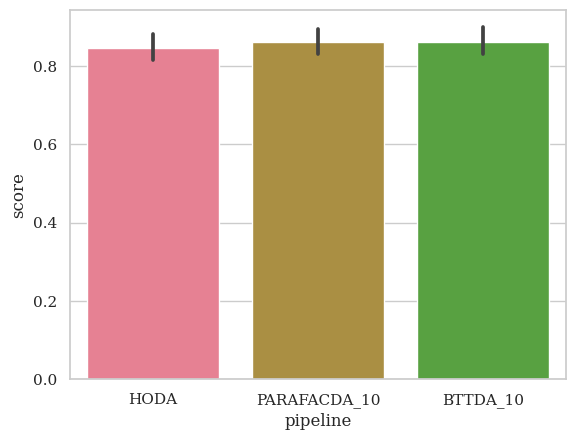

In [9]:
sns.barplot(data=results, x='pipeline', y='score')

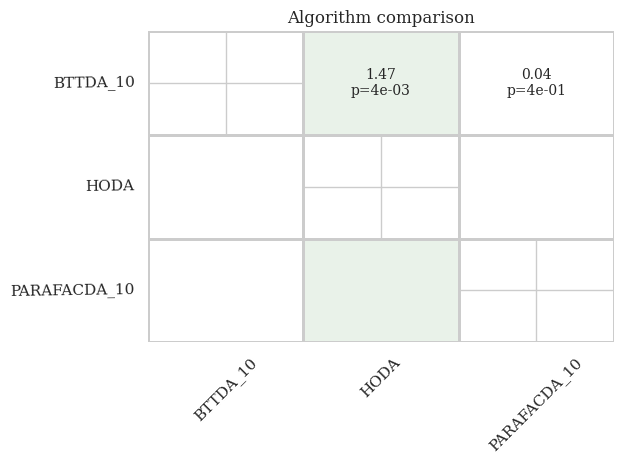

In [10]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T, simplify=False)
plt.show()

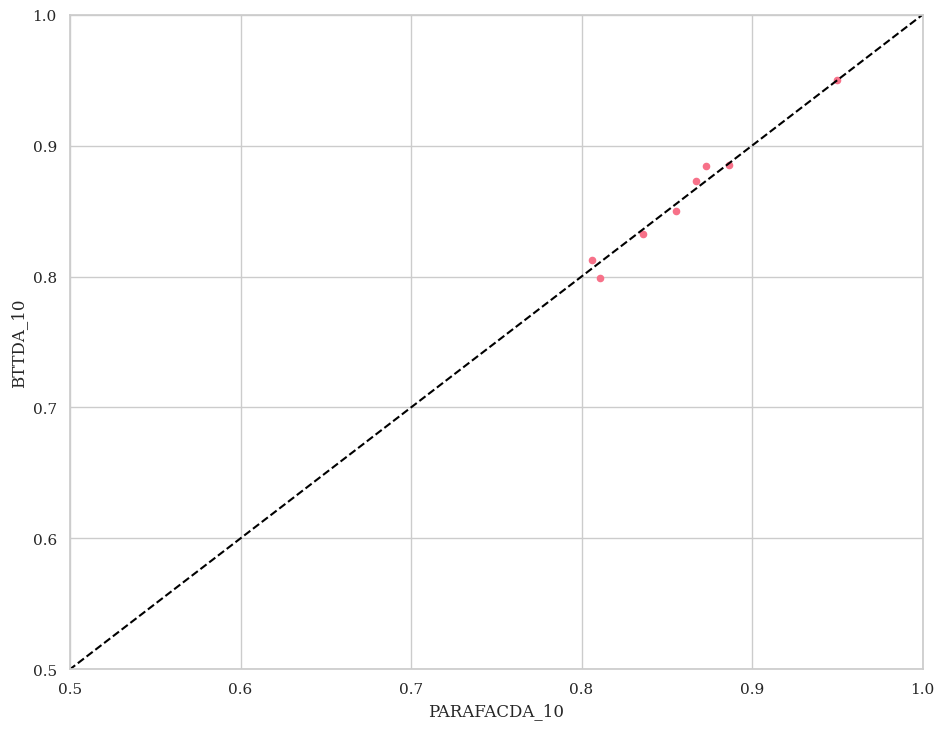

In [11]:
from moabb.analysis.plotting import paired_plot
_ = paired_plot(results, 'PARAFACDA_10', 'BTTDA_10')

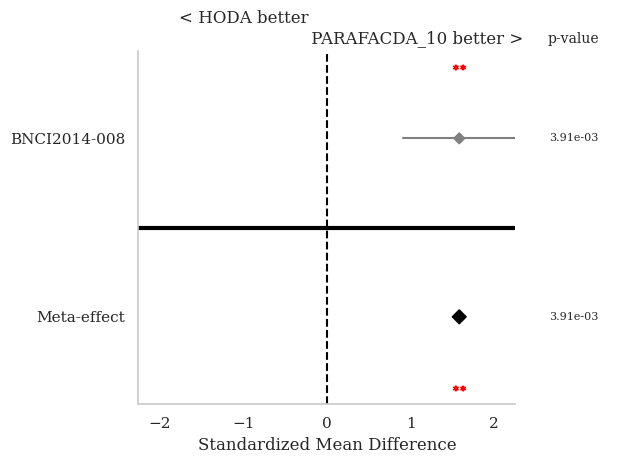

In [15]:
import moabb.analysis.plotting as moabb_plt

_ = moabb_plt.meta_analysis_plot(stats, 'PARAFACDA_10', 'HODA')

In [13]:
results[results['dataset'] == 'BrainInvaders2015b'].groupby(['session', 'subject']).aggregate('count')

,,score,time,samples,channels,n_sessions,dataset,pipeline
session,subject,,,,,,,
